# The Cost of Discretion

## What public FIA data can and cannot show about Formula 1 stewarding, 2018-2025

**Oversight report | Python, Jupyter, SQL/DuckDB | Evidence frozen through the 2025 season**

The main finding is simple: **the penalty written in a decision is not always what it costs on
track**. This report calls the written penalty the *nominal sanction* and the actual loss in places,
points, or starting position the *realized burden*. In the independently reviewed pilot, one
five-second penalty cost a podium and six points. Another changed no position or points. A served
ten-second penalty changed strategy and traffic, so subtracting ten seconds from the final time
would give a misleading answer. A later grid penalty had a clear effect on the next starting grid,
but not a measurable effect on the race result.

This difference matters for fairness, but it does not prove that a decision was wrong. Stewards
judge conduct and responsibility; penalties are not designed simply to repay the affected driver.
The report therefore studies **decision consistency**, **penalty burden**, and **affected-driver
harm** separately.

The full dataset is complete enough to audit the evidence process and test whether the study design
is workable. It is not ready for a league-wide fairness or nationality estimate because the outcome
records have not completed independent review. That limit is part of the result, not a footnote.

In [1]:
# ruff: noqa: E402
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".jupyter" / "mplconfig"))

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from f1stewards.config import load_outcome_model_spec
from f1stewards.model_validation import (
    nationality_overlap_diagnostics,
    simulate_nationality_power,
)

DB_PATH = ROOT / "data" / "processed" / "f1_stewarding.duckdb"
PILOT = ROOT / "data" / "manual" / "reconciled" / "pilot-41f4502411c2"
GENERATED = ROOT / "reports" / "generated"
GENERATED.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
COLORS = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 120)

## Executive decision

Four conclusions follow:

1. **Penalty seconds alone do not measure fairness.** When a penalty is applied, the gaps between
   cars, repair stops, retirements, and delayed sanctions determine its actual cost.
2. **The current study cannot support a British-bias estimate.** The groups are reasonably
   comparable on measured factors, but the sample is too small to detect subtle differences.
3. **Treat the full dataset as work under review, not as released findings.** Source coverage is
   complete; independent verification is not.
4. **Ask the FIA for structured, versioned decisions.** A machine-readable incident ID, roles,
   applicable guidance, penalty timing, and correction history would make audits more reliable.

## 1. Population and release status

,stage,count,interpretation
0,FIA archive records,9467,Official event-document inventory
1,Outcome labels,2003,Version-preserving outcome population
2,Live outcome PDFs,1984,Retrieved and parsed
3,Content-confirmed decisions,1952,One live decision seed each
4,Possible Race/Sprint cases,348,Study-design checks only
5,Cases approved for reporting,0,Approved findings


,control,status,observed,expected
0,workspace_integrity,pass,19,19
1,document_dispositions_complete,fail,0,2003
2,selected_candidate_panel_identity_complete,pass,0,0
3,adjudication_coding_complete,fail,0,1952
4,exclusion_qa_complete,fail,0,486
5,final_primary_population_nonempty,fail,0,> 0
6,final_primary_accused_identity_complete,pass,0,0
7,final_primary_binary_outcome_complete,pass,0,0
8,analytical_release,fail,one or more fail,all prerequisite controls pass


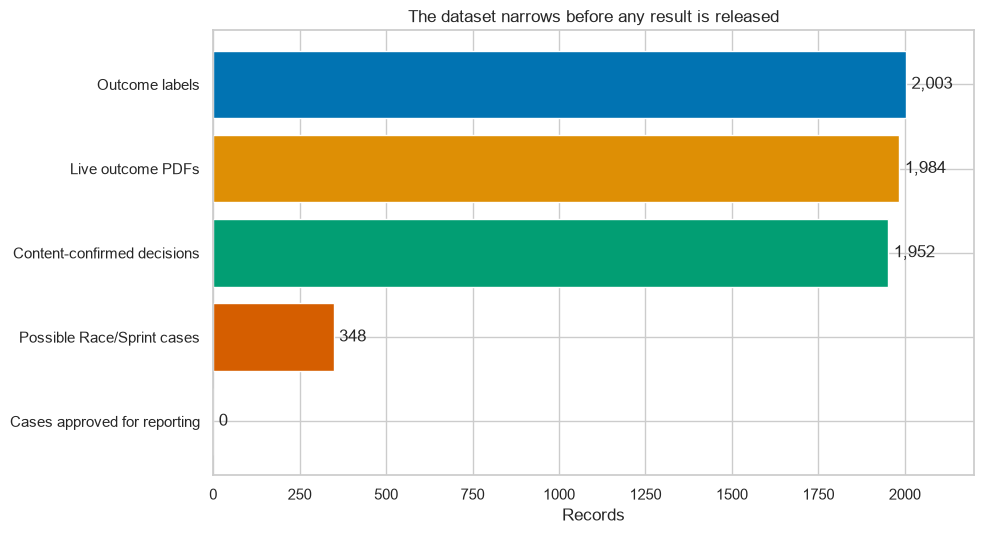

In [2]:
with duckdb.connect(str(DB_PATH), read_only=True) as connection:
    latest_build = connection.sql(
        """SELECT * FROM metadata.analysis_feature_builds
           ORDER BY built_at_utc DESC, feature_build_id DESC LIMIT 1"""
    ).df().iloc[0]
    controls = connection.sql(
        """SELECT control, status, observed, expected
           FROM analysis.feature_release_controls
           WHERE feature_build_id = ? ORDER BY control_order""",
        params=[latest_build["feature_build_id"]],
    ).df()
    features = connection.sql(
        """SELECT * FROM analysis.v_latest_adjudication_features
           ORDER BY adjudication_instance_id"""
    ).df()

flow = pd.DataFrame(
    {
        "stage": [
            "FIA archive records",
            "Outcome labels",
            "Live outcome PDFs",
            "Content-confirmed decisions",
            "Possible Race/Sprint cases",
            "Cases approved for reporting",
        ],
        "count": [
            9_467,
            2_003,
            1_984,
            1_952,
            len(features),
            int(features["reporting_eligible"].sum()),
        ],
        "interpretation": [
            "Official event-document inventory",
            "Version-preserving outcome population",
            "Retrieved and parsed",
            "One live decision seed each",
            "Study-design checks only",
            "Approved findings",
        ],
    }
)
assert flow["count"].tolist() == [9467, 2003, 1984, 1952, 348, 0]
assert latest_build["release_status"] == "blocked_pending_human_review"
display(flow)
display(controls)

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_flow = flow.iloc[1:].copy()
bars = ax.barh(plot_flow["stage"], plot_flow["count"], color=COLORS[:5])
ax.invert_yaxis()
ax.set(title="The dataset narrows before any result is released", xlabel="Records")
ax.bar_label(bars, labels=[f"{value:,}" for value in plot_flow["count"]], padding=4)
ax.set_xlim(0, 2200)
plt.tight_layout()
fig.savefig(GENERATED / "population_flow.png", dpi=180, bbox_inches="tight")
plt.show()

All 173 completed championship events are covered. The archive contains 2,003 outcome records,
including corrected and recalled versions, and 1,952 live records are confirmed steward decisions.
The analysis contains 348 possible Race/Sprint cases across 131 events, but **zero are approved for
full-corpus reporting**. The release rules block results until document classification, case coding,
and the 486-row exclusion audit receive independent review.

The project can report source coverage, data quality, reviewed pilot cases, and study-design checks
that do not use penalty outcomes. It cannot yet publish league-wide penalty rates, anomaly rankings,
guideline-departure rates, or nationality effects.

## 2. Exploratory data analysis: what the candidate set contains

,incident_family,candidate_adjudications,incident_family_label
0,causing_collision,235,Causing Collision
1,gaining_advantage_off_track,54,Gaining Advantage Off Track
2,forcing_off_track,43,Forcing Off Track
3,unsafe_rejoin,8,Unsafe Rejoin
4,multiple_defensive_moves,6,Multiple Defensive Moves
5,moving_under_braking,2,Moving Under Braking


,season,candidate_adjudications
0,2018,54
1,2019,44
2,2020,18
3,2021,30
4,2022,46
5,2023,39
6,2024,54
7,2025,63


,feature_label_status,population_status,rows
0,incomplete_human_coding,incomplete_human_coding,174
1,incomplete_human_coding,source_coded_primary_pending_human,174


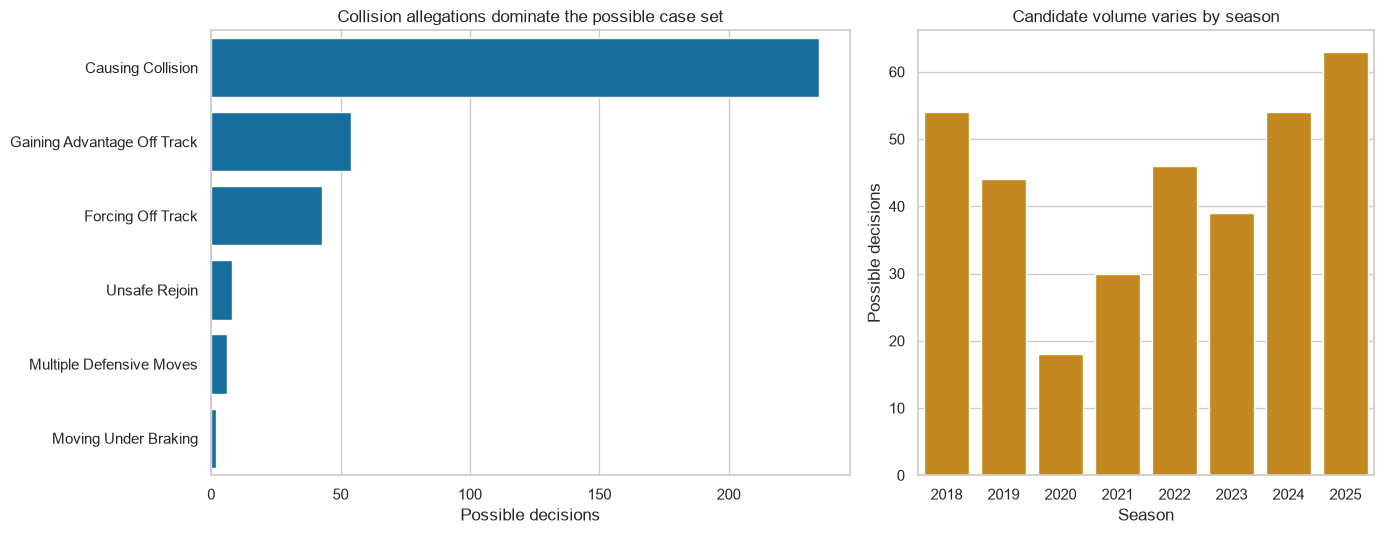

In [3]:
family_counts = (
    features.groupby("incident_family", dropna=False)
    .size()
    .rename("candidate_adjudications")
    .sort_values(ascending=False)
    .reset_index()
)
family_counts["incident_family_label"] = (
    family_counts["incident_family"].str.replace("_", " ").str.title()
)
season_counts = features.groupby("season").size().rename("candidate_adjudications").reset_index()
label_counts = (
    features.groupby(["feature_label_status", "population_status", "feature_provenance"])
    .size().rename("rows").reset_index()
)
display(family_counts)
display(season_counts)
display(label_counts[["feature_label_status", "population_status", "rows"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.4, 1]})
sns.barplot(
    data=family_counts,
    y="incident_family_label",
    x="candidate_adjudications",
    color=COLORS[0],
    ax=axes[0],
)
axes[0].set(
    title="Collision allegations dominate the possible case set",
    xlabel="Possible decisions",
    ylabel="",
)
sns.barplot(
    data=season_counts,
    x="season",
    y="candidate_adjudications",
    color=COLORS[1],
    ax=axes[1],
)
axes[1].set(
    title="Candidate volume varies by season",
    xlabel="Season",
    ylabel="Possible decisions",
)
plt.tight_layout()
fig.savefig(GENERATED / "provisional_candidate_composition.png", dpi=180, bbox_inches="tight")
plt.show()

The possible case set contains 235 collision decisions, 54 gaining-advantage cases, 43 forcing-off-
track cases, and 16 cases in three smaller categories. Twenty-five decisions involve more than one
affected driver. The data therefore keep a separate driver-role table instead of forcing every
incident into a two-car format. Half the rows have one completed human coding pass; half still rely
on machine-assisted coding. All rows still need independent verification.

The plots show workload and case mix only. Outcome rates are withheld because unreviewed labels
could make a parsing error look like a stewarding trend.

## 3. Nationality: diagnose the design before estimating an effect

,value
rows,348
events,131
exposed_rows,44
unexposed_rows,304
exposure_prevalence,0.126437
propensity_auc,0.705181
propensity_min,0.01
propensity_max,0.618251
common_support_lower,0.018238
common_support_upper,0.368474


,baseline_probability,target_risk_difference,target_exposure_log_odds,repetitions,successful_fits,successful_fit_fraction,simulation_fit_status,detection_power,target_power,power_target_met,monte_carlo_standard_error,median_estimated_log_odds,median_cluster_robust_se,exposed_rows,unexposed_rows,event_clusters,event_random_intercept_sd,interpretation_status
0,0.5,0.05,0.200671,500,500,1.000,stable,0.092,0.8,False,0.012926,0.212235,0.354761,44,304,131,0.35,design_simulation_not_effect_estimate
1,0.5,0.10,0.405465,500,500,1.000,stable,0.182,0.8,False,0.017255,0.418464,0.356355,44,304,131,0.35,design_simulation_not_effect_estimate
2,0.5,0.15,0.619039,500,500,1.000,stable,0.436,0.8,False,0.022177,0.652742,0.365617,44,304,131,0.35,design_simulation_not_effect_estimate
3,0.5,0.20,0.847298,500,500,1.000,stable,0.606,0.8,False,0.021852,0.840671,0.377859,44,304,131,0.35,design_simulation_not_effect_estimate
4,0.7,0.05,0.251314,500,500,1.000,stable,0.082,0.8,False,0.012270,0.242856,0.395914,44,304,131,0.35,design_simulation_not_effect_estimate
5,0.7,0.10,0.538997,500,500,1.000,stable,0.258,0.8,False,0.019567,0.559129,0.427577,44,304,131,0.35,design_simulation_not_effect_estimate
6,0.7,0.15,0.887303,500,498,0.996,stable,0.528,0.8,False,0.022326,0.935198,0.471673,44,304,131,0.35,design_simulation_not_effect_estimate
7,0.7,0.20,1.349927,500,496,0.992,stable,0.788,0.8,False,0.018279,1.414463,0.540832,44,304,131,0.35,design_simulation_not_effect_estimate


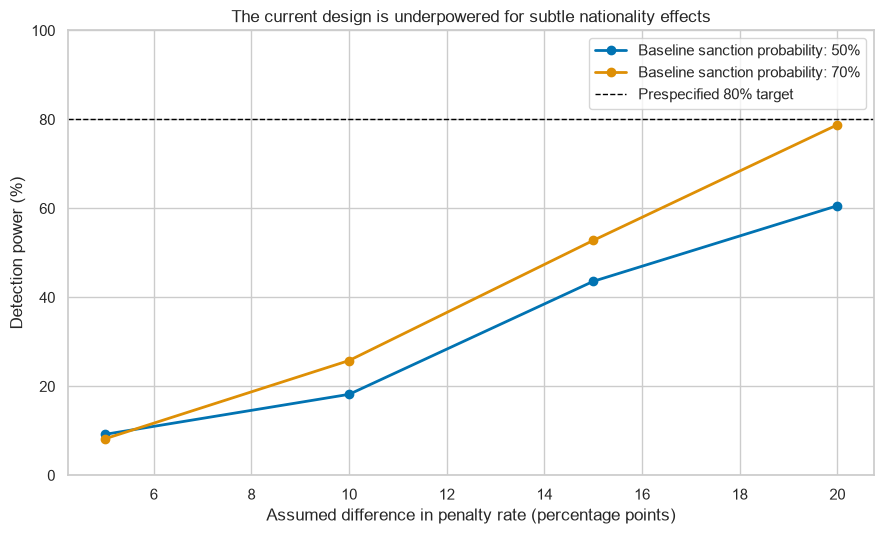

In [4]:
design_features = features.drop(columns=["sanction_outcome"]).copy()
spec = load_outcome_model_spec()
overlap = nationality_overlap_diagnostics(design_features, spec)
power = simulate_nationality_power(design_features, spec)
summary = overlap.summary.iloc[0]

display(overlap.summary.T.rename(columns={0: "value"}))
display(power)
assert int(summary["exposed_rows"]) == 44
assert int(summary["unexposed_rows"]) == 304
assert power["detection_power"].max() < 0.80

fig, ax = plt.subplots(figsize=(9, 5.5))
for index, (baseline, group) in enumerate(power.groupby("baseline_probability")):
    ax.plot(
        group["target_risk_difference"] * 100,
        group["detection_power"] * 100,
        marker="o",
        linewidth=2,
        color=COLORS[index],
        label=f"Baseline sanction probability: {baseline:.0%}",
    )
ax.axhline(80, color="black", linestyle="--", linewidth=1, label="Prespecified 80% target")
ax.set(
    title="The current design is underpowered for subtle nationality effects",
    xlabel="Assumed difference in penalty rate (percentage points)",
    ylabel="Detection power (%)",
    ylim=(0, 100),
)
ax.legend(frameon=True)
plt.tight_layout()
fig.savefig(GENERATED / "nationality_power.png", dpi=180, bbox_inches="tight")
plt.show()

power.to_csv(GENERATED / "nationality_power.csv", index=False)
overlap.summary.to_csv(GENERATED / "nationality_overlap_summary.csv", index=False)

The design contains 44 British and 304 other accused-driver cases. Estimated common support is
97.4%, meaning most cases have a reasonable comparison in the other group. Overlap weighting lowers
the largest measured group imbalance from 0.526 to 0.040. This improves comparability, but it does
not fix the small sample.

Across the prespecified simulations, estimated power ranges from 8.2% to 78.8%. Even a large
20-percentage-point difference misses the 80% target in one scenario; 5-10-point differences are
much harder to detect. **The nationality result is inconclusive. It is not evidence of either bias
or no bias.** This design check did not use observed penalty outcomes.

## 4. The reviewed pilot: written penalty is not actual cost

,case,written penalty,application,actual penalty cost,affected-driver evidence
0,"Pérez → Norris, Abu Dhabi 2023",5 seconds + 2 points,added after race,P4→P2 without penalty; 6 points and podium,Norris P4→P5 next lap; 0.167 s relative swing
1,"Tsunoda → Colapinto, Austria 2025",10 seconds + 2 points,served during race,not estimable from the final classification,no immediate place loss; possible damage alleged
2,"Colapinto → Piastri, Austria 2025",5 seconds + 1 point,added after race,0 positions; 0 points,forced off; seconds/win effect not estimable
3,"Antonelli → Verstappen, Austria 2025",3-grid places + 2 points,next event,exact P7→P10 start; race effect not estimable,confirmed incident-caused retirement


,count
affected-driver records,9
fault-established records,4
confirmed damage records,2
alleged damage records,1
incident-caused retirements,1
incident-responsive repair stops,0
observed positive position losses,3
persistent pace estimates released,0


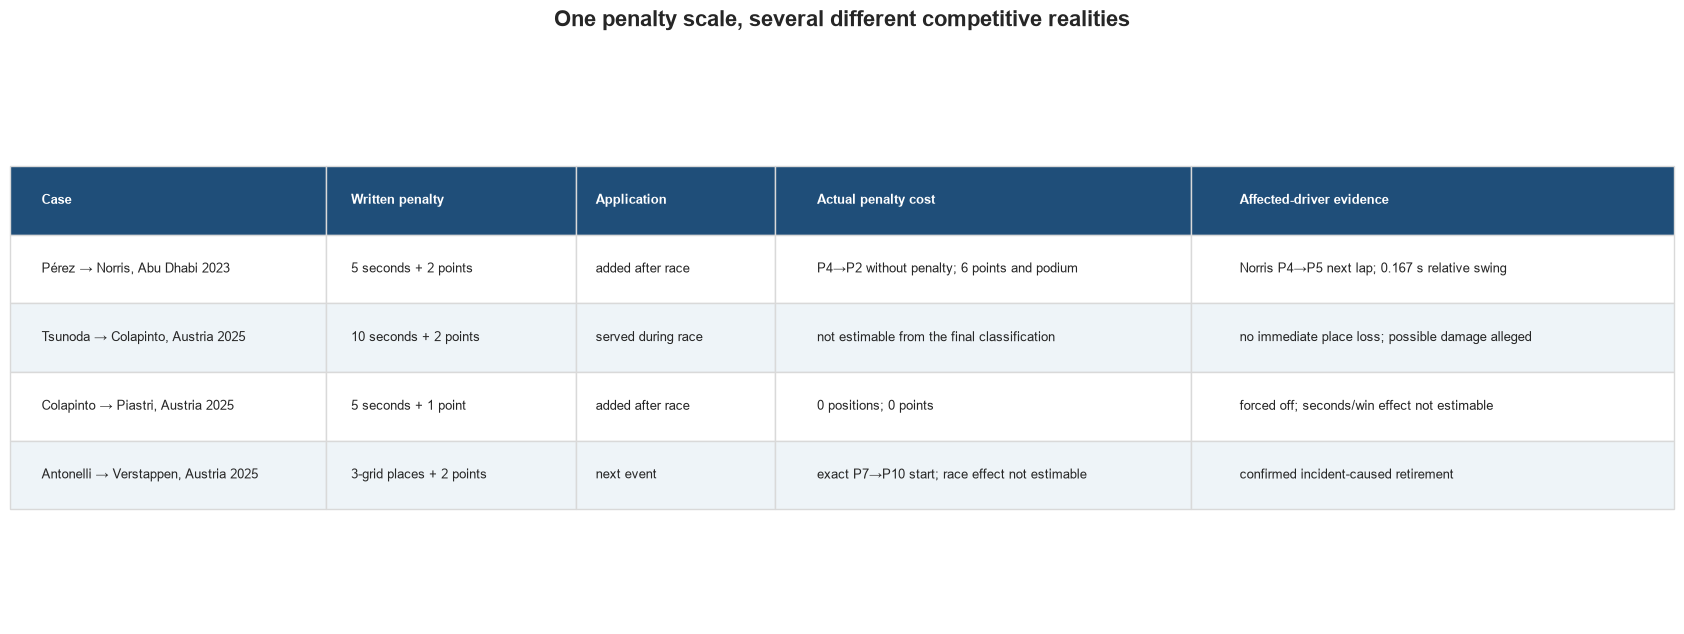

In [5]:
adjudications = pd.read_csv(PILOT / "adjudications.csv")
impacts = pd.read_csv(PILOT / "impact_assessments.csv")
harms = pd.read_csv(PILOT / "harm_assessments.csv")
cross_event = pd.read_csv(PILOT / "cross_event_sanction_effects.csv")

assert len(adjudications) == 9
assert len(impacts) == 4
assert len(harms) == 9
assert set(adjudications["review_status"]) == {"double_coded"}
assert set(impacts["review_status"]) == {"double_coded"}
assert set(harms["review_status"]) == {"double_coded"}

pilot_matrix = pd.DataFrame(
    [
        {
            "case": "Pérez → Norris, Abu Dhabi 2023",
            "written penalty": "5 seconds + 2 points",
            "application": "added after race",
            "actual penalty cost": "P4→P2 without penalty; 6 points and podium",
            "affected-driver evidence": "Norris P4→P5 next lap; 0.167 s relative swing",
        },
        {
            "case": "Tsunoda → Colapinto, Austria 2025",
            "written penalty": "10 seconds + 2 points",
            "application": "served during race",
            "actual penalty cost": "not estimable from the final classification",
            "affected-driver evidence": "no immediate place loss; possible damage alleged",
        },
        {
            "case": "Colapinto → Piastri, Austria 2025",
            "written penalty": "5 seconds + 1 point",
            "application": "added after race",
            "actual penalty cost": "0 positions; 0 points",
            "affected-driver evidence": "forced off; seconds/win effect not estimable",
        },
        {
            "case": "Antonelli → Verstappen, Austria 2025",
            "written penalty": "3-grid places + 2 points",
            "application": "next event",
            "actual penalty cost": "exact P7→P10 start; race effect not estimable",
            "affected-driver evidence": "confirmed incident-caused retirement",
        },
    ]
)
display(pilot_matrix)

harm_summary = pd.Series(
    {
        "affected-driver records": len(harms),
        "fault-established records": int(
            (harms["responsibility_status"] == "fault_established").sum()
        ),
        "confirmed damage records": int((harms["damage_evidence"] == "confirmed").sum()),
        "alleged damage records": int((harms["damage_evidence"] == "alleged").sum()),
        "incident-caused retirements": int((harms["retirement_status"] == "incident_caused").sum()),
        "incident-responsive repair stops": int((harms["repair_stop_required"] == "yes").sum()),
        "observed positive position losses": int((harms["net_positions_lost_observed"] > 0).sum()),
        "persistent pace estimates released": int(
            harms["persistent_loss_seconds_estimate"].notna().sum()
        ),
    },
    name="count",
)
display(harm_summary.to_frame())

table_fig, table_ax = plt.subplots(figsize=(17, 6.5))
table_ax.axis("off")
wrapped = pilot_matrix.copy()
wrapped.columns = [
    "Case",
    "Written penalty",
    "Application",
    "Actual penalty cost",
    "Affected-driver evidence",
]
table = table_ax.table(
    cellText=wrapped.values,
    colLabels=wrapped.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.19, 0.15, 0.12, 0.25, 0.29],
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 3.6)
for (row, _col), cell in table.get_celld().items():
    cell.set_edgecolor("#d9d9d9")
    if row == 0:
        cell.set_facecolor("#1f4e79")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#eef4f8")
table_ax.set_title(
    "One penalty scale, several different competitive realities",
    fontsize=16,
    weight="bold",
    pad=18,
)
plt.tight_layout()
table_fig.savefig(GENERATED / "pilot_harm_sanction_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

The pilot covers nine decisions from Austria 2019, Abu Dhabi 2023, and Austria 2025. Independent
reviewers agreed on all 26 case, impact, harm, location, relationship, and cross-event records.

The pilot does not show that any penalty was necessarily unfair. It shows that the number written in
a decision does not tell us its actual competitive cost:

- Perez's post-race five seconds cost two places, six points, and a podium.
- Colapinto's post-race five seconds changed no place and no points.
- Tsunoda served ten seconds during the race. Because that changed strategy and traffic, subtracting
  ten seconds from his final time would be misleading.
- Antonelli's delayed penalty moved his next start from P7 to P10 exactly, but the wet-race result
  depended on too many other factors to isolate.

Harm to the affected driver also takes different forms. Four pilot records establish another
driver's fault. They include one incident-caused retirement, one next-lap position loss, one claim
of possible damage without an immediate place loss, and one off-track excursion whose time cost
could not be isolated. No estimate of lasting per-lap damage met the clean-lap evidence rule. Severe
harm does not by itself prove fault, and a penalty for conduct is not automatic compensation.

## 5. Public-guideline audit: a bounded pilot finding

In [6]:
guideline_pilot = adjudications.loc[
    adjudications["guideline_regime"] == "public_driving_and_penalty_guidelines",
    ["adjudication_id", "incident_family", "outcome_family", "conformance_status", "coding_notes"],
]
display(guideline_pilot)
display(guideline_pilot["conformance_status"].value_counts().rename("cases").to_frame())
assert len(guideline_pilot) == 5
assert set(guideline_pilot["conformance_status"]) == {"conformant", "mitigated"}

,adjudication_id,incident_family,outcome_family,conformance_status,coding_notes
4,adj-2025-aut-r31-t4-22,causing_collision,time_penalty,conformant,Official reason says Car 22 was fully at fault and did not earn the corner; 2 points are within the published 3-poin...
5,adj-2025-aut-r4-t3-43,forcing_off_track,no_further_action,conformant,Official reason finds Car 87 lacked outside-overlap priority so Car 43 could use the regular racing line; lap is sup...
6,adj-2025-aut-r54-t34-43,forcing_off_track,time_penalty,mitigated,Decision explicitly mitigates because Car 22 obscured Car 81; race-control evidence places the event on global lap 5...
7,adj-2025-aut-r1-t3-12,causing_collision,grid_penalty,conformant,Decision says Car 12 was fully at fault but records evasive action and a non-blatant move; grid penalty was used bec...
8,adj-2025-aut-r15-t3-22,forcing_off_track,no_further_action,conformant,Doc 46 appears to replace unavailable recalled Doc 39; the reason finds all inside-overtake requirements satisfied a...


,cases
conformance_status,
conformant,4
mitigated,1


All five reviewed 2025 Austrian decisions either matched the public guideline or explained a
mitigating factor: four matched the baseline and one was mitigated. This shows that the method can
separate a guideline match, mitigation, and a departure. It is **not** a league-wide 2025 rate; the
full season has not passed independent review.

## 6. How to strengthen the study

The next version will be stronger if it narrows the main question before adding more models. The
best design has two linked but separate tracks:

1. **Decision consistency:** among similar incidents that reached the stewards, did similar conduct
   and responsibility findings receive similar penalties?
2. **Competitive consequence:** what did the incident cost the affected driver, and what did the
   penalty actually cost the penalized driver?

The following changes would improve the evidence most:

1. **Finish a feasible independent-review plan.** Review all 348 possible analytical cases, every
   corrected, recalled, ambiguous, and multi-car case, and the prespecified 486-row sample of
   exclusions. Report false-exclusion rates by sample group and expand review when an error
   threshold is crossed. This would preserve a strict release standard without treating every
   administrative document as equally risky.
2. **Study the referral stage.** FIA decision PDFs only show incidents that reached a formal
   decision. Race Control messages could add the earlier path from "noted" to "investigated" to
   "formally decided." This would not capture every on-track event, but it would make the current
   denominator limitation smaller and measurable.
3. **Use matched cases as the main consistency test.** Build comparison sets within incident type,
   rule era, session type, lap phase, and responsibility language. Show close case pairs first, then
   use a multilevel model as a sensitivity check. Uncertainty should be grouped by incident and
   event so related decisions are not treated as independent evidence.
4. **Study harm deeply on a representative sample.** Select collision cases across penalty outcome,
   damage, repair-stop, and retirement groups. Estimate lasting pace loss only from clean laps and
   compare the affected car with suitable teammate or field controls. Report an uncertainty range
   and keep "not estimable" when the race does not provide a credible comparison.
5. **Keep nationality secondary.** State the minimum effect the sample can detect before estimating
   an association. If the study cannot detect a difference small enough to matter, report the design
   limit instead of making nationality a headline result.
6. **Measure reviewer reliability by field.** The full review should report disagreement rates for
   incident type, responsibility, penalty, damage, and inclusion. A chance-adjusted agreement
   measure can remain in the technical appendix; the main report should show where reviewers
   actually differ.

## 7. Conclusions and recommendations

### Conclusion

The public record does not currently support a reliable conclusion that F1 stewarding was
systematically inconsistent or nationally biased from 2018-2025. This does not clear the system of
either problem. It means the evidence is not yet strong enough to decide: full-dataset labels are
unreleased, incidents that were never referred are missing, some steward nationalities are
unconfirmed, and the British-driver comparison is too small for subtle effects.

The report does support a narrower conclusion: **the penalty column alone cannot measure competitive
fairness.** A useful comparison needs four linked facts: who was found responsible, the penalty
written in the decision, what that penalty actually cost, and the harm to each affected driver. The
pilot shows that these can differ even when the written penalties look similar.

### Recommendations

1. **Publish structured decisions.** Add stable incident and decision IDs, driver roles,
   session/lap/turn, finding, penalty timing, and version status.
2. **Version the guidance.** Publish the exact guideline text effective at each event and identify
   the normal penalty and any written aggravating or mitigating factors.
3. **Report consequences separately.** Keep seconds, starting positions, finishing positions,
   points, repair, damage, and retirement separate instead of combining them into one fairness
   score.
4. **Show the referral boundary.** Formal decisions describe only cases sent to the stewards. A full
   audit also needs data on what was noted, investigated, and not referred.
5. **Use models to find cases for review.** A model can flag unusual decisions; it cannot decide
   that a steward was wrong.
6. **Release findings only when their checks pass.** Nationality and guideline results should remain
   descriptive or inconclusive until review, comparability, power, and sensitivity checks pass.

### Evidence grades

| Finding | Grade | Release decision |
|---|---|---|
| 2018–2025 source inventory and lineage | A | Reportable |
| Reviewed pilot penalty-impact calculations | A | Reportable for pilot cases |
| Reviewed pilot harm and guideline case audit | D | Case-study evidence; no population rate |
| Full-corpus consistency and anomaly results | U | Withheld pending independent review |
| British-driver association | U | Inconclusive; effect not estimated |
| Panel-nationality association | U | Withheld pending complete source evidence |

The project also demonstrates an auditable data workflow: source history is preserved, Python and
DuckDB transformations are tested, FastF1 timing data are kept separate from FIA fault findings,
review changes are traceable, the Jupyter analysis is executable, and the Snowflake/Snowsight
package can be validated without credentials. Most importantly, the workflow blocks a finding when
its evidence checks have not passed.

## Technical appendix: reproducibility and limitations

- **Population:** 173 completed F1 championship events, 2018-2025; Race and Sprint primary sessions.
- **Primary unit:** one accused-driver adjudication; multi-car affected roles retained separately.
- **Authorities:** FIA decisions and classifications; FastF1 used for timing enrichment, not fault.
- **Storage/query:** typed Parquet exports and DuckDB schemas; Snowflake/Snowsight SQL package is
  locally validated but not claimed as remotely deployed.
- **Validation:** 19 editable-workspace controls, schema contracts, SQL integrity checks,
  test suite, checksum manifests, and content-addressed reconciliation.
- **Referral limitation:** incidents never formally sent to the stewards are not in the denominator.
- **Human-review limitation:** zero of the 4,441 full-corpus review targets meet the independent
  completion status; the 486-row stratified exclusion audit is still pending.
- **Power limitation:** the current nationality design is not powered for subtle associations.
- **Counterfactual limitation:** for penalties served during a race, repair effects, and race
  outcomes, the no-penalty or no-incident result usually cannot be found by simple time subtraction.
- **Causal limitation:** an observed position or time change does not prove what would have happened
  without the incident.

Rebuild the feature layer with `f1stewards build-analysis-features`, execute notebooks 04-06, run
`pytest` and `ruff check`, and inspect `analysis.feature_release_controls` before interpreting any
result table. The report blocks a claim when those controls have not approved it.